<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Why Training Fails: Noise and Reproducibility

_Prepared by Claudia Zendejas-Morales_

Training can fail even when the objective function and optimizer are formally correct. In quantum machine learning, poor progress may come from almost flat landscapes, from noisy objective evaluations, or from experimental protocols that make one run look much better than another. Those are different failure modes, and they should not be diagnosed with the same evidence.

The discussion below separates them on purpose. We start with barren plateaus as a gradient-concentration problem, then move to shot noise and seed-dependent gradient variability, and finally turn to overfitting and reproducibility controls in a small supervised QML workflow. As in the rest of the module, we use $C$ for generic variational cost functions and $\mathcal{L}$ for supervised empirical objectives.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/why-training-fails-map.png" alt="Three distinct reasons why QML training can fail" width="800"/>
</p>

The same disappointing training curve can hide very different causes. Flat landscapes, noisy estimators, and weak generalization all interfere with optimization, but they do so in different ways.


## Three failure modes are not the same

In a variational QML workflow, the classical optimizer sees only numbers produced by repeated circuit evaluations. If those numbers change too little with the parameters, training stalls because the landscape is effectively flat. If those numbers fluctuate strongly from run to run, the optimizer can move in unstable directions. If those numbers improve only on the training set, the model may simply be memorizing a small dataset instead of learning a robust pattern.

That distinction matters because the corresponding remedies are different. Barren plateaus point toward circuit design, initialization, or cost locality. Shot noise points toward estimator variance, shot allocation, or hardware quality. Overfitting and reproducibility point toward data splits, early stopping, repeated runs, and careful reporting. The rest of the notebook treats those cases separately rather than collapsing them under the single label of “bad training.”


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Low accuracy does not identify the cause</b><br>
A poor final metric is only an outcome. By itself, it does not tell us whether the model saw almost no gradient, whether the gradient estimate was too noisy to trust, or whether the model overfit a tiny training set. QML experiments become interpretable only after those possibilities are separated.
</div>


## Flat landscapes and barren plateaus

Let $C(\boldsymbol{\theta})$ be a generic variational cost function with trainable parameters $\boldsymbol{\theta} = (\theta_1, \dots, \theta_P)$. Training relies on components such as

$$
\frac{\partial C}{\partial \theta_m},
\qquad
m \in \{1, \dots, P\}
$$

A barren plateau is usually discussed through gradient concentration: for broad families of expressive or random circuits, one finds that typical gradient components become very small, often through a vanishing variance such as

$$
\mathbb{E}_{\boldsymbol{\theta}}\!\left[\frac{\partial C}{\partial \theta_m}\right] = 0,
\qquad
\mathrm{Var}_{\boldsymbol{\theta}}\!\left[\frac{\partial C}{\partial \theta_m}\right] \to 0
$$

as the problem size or circuit expressivity grows. When this happens, an optimizer may still be well defined, but the update direction carries very little signal. One practical diagnostic is therefore the gradient norm

$$
\Gamma(\boldsymbol{\theta}) = \left\lVert \nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}) \right\rVert_2
$$

If typical random initializations already yield very small values of $\Gamma$, training is likely to be fragile long before one launches a long optimization run.


<div align="center">
  <img src="images/barren-plateau-concept.png" alt="Conceptual view of a trainable region versus a barren plateau" width="900">
</div>

The figure contrasts two optimization landscapes under the same vertical scale. On the left, the objective changes perceptibly when the parameters move, so the local slope provides a usable update signal and optimization can follow that variation. On the right, the surface is still smooth, but it is much flatter around a broad region of parameter space. That is the essential intuition behind a barren plateau: the objective is not exactly constant, yet typical local parameter changes produce only tiny changes in the cost, so gradient-based training receives very weak guidance.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>A small notebook experiment is only a warning sign</b><br>
The code below does <b>not</b> prove an asymptotic barren plateau theorem. It only shows a finite-size warning sign: typical gradient norms can shrink markedly as the circuit becomes larger. For the original barren-plateau result, see <a href="https://arxiv.org/abs/1803.11173">McClean et al. (2018)</a>. For a broader review of trainability issues in variational quantum algorithms, see <a href="https://arxiv.org/abs/2012.09265">Cerezo et al. (2021)</a>. For the role of hardware noise in generating flat landscapes, see <a href="https://arxiv.org/abs/2007.14384">Wang et al. (2021)</a>.
</div>


## Example 1: A small gradient-concentration diagnostic

To isolate the flat-landscape issue, we first use a generic cost rather than a supervised empirical objective. Consider an $n$-qubit hardware-efficient ansatz of depth $L$,

$$
U_A(\boldsymbol{\theta})
=
\prod_{\ell=1}^{L}
\left[
\prod_{q=0}^{n-1} R_y\!\left(\theta^{(y)}_{q,\ell}\right) R_z\!\left(\theta^{(z)}_{q,\ell}\right)
\right]
\left[
\prod_{q=0}^{n-2} \mathrm{CZ}_{q,q+1}
\right]
$$

with $P = 2nL$ trainable parameters. Since this diagnostic does not use a data-dependent feature map, the prepared state is simply

$$
|\psi_{\mathrm{out}}(\boldsymbol{\theta})\rangle = U_A(\boldsymbol{\theta}) |0\rangle^{\otimes n}
$$

and we define the global cost

$$
C_{\mathrm{global}}(\boldsymbol{\theta})
=
\langle \psi_{\mathrm{out}}(\boldsymbol{\theta}) |
Z_0 \otimes Z_1 \otimes \cdots \otimes Z_{n-1}
| \psi_{\mathrm{out}}(\boldsymbol{\theta}) \rangle
$$

For repeated random initializations $\boldsymbol{\theta}^{(1)}, \dots, \boldsymbol{\theta}^{(R)}$, the diagnostic below tracks the distribution of

$$
\Gamma\!\left(\boldsymbol{\theta}^{(r)}\right)
=
\left\lVert \nabla_{\boldsymbol{\theta}} C_{\mathrm{global}}\!\left(\boldsymbol{\theta}^{(r)}\right) \right\rVert_2
$$

The next cell sets up all reusable helpers used in the rest of the notebook: generic variational costs for the barren-plateau diagnostic, one-qubit supervised BCE models for the shot-noise study, and a small repeated-run training workflow for the reproducibility study.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


def make_hardware_efficient_qnode(n_qubits, observable="global"):
    device = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(device)
    def circuit(weights, depth):
        idx = 0
        for _ in range(depth):
            for q in range(n_qubits):
                qml.RY(float(weights[idx]), wires=q)
                idx += 1
                qml.RZ(float(weights[idx]), wires=q)
                idx += 1
            for q in range(n_qubits - 1):
                qml.CZ(wires=[q, q + 1])
        if observable == "global":
            measured = qml.PauliZ(0)
            for q in range(1, n_qubits):
                measured = measured @ qml.PauliZ(q)
        elif observable == "local":
            measured = qml.PauliZ(0)
        else:
            raise ValueError("observable must be 'global' or 'local'")
        return qml.expval(measured)

    return circuit


HARDWARE_EFFICIENT_QNODES = {}


def generic_cost(weights, n_qubits, depth, observable="global"):
    key = (n_qubits, observable)
    if key not in HARDWARE_EFFICIENT_QNODES:
        HARDWARE_EFFICIENT_QNODES[key] = make_hardware_efficient_qnode(n_qubits, observable)
    qnode = HARDWARE_EFFICIENT_QNODES[key]
    return float(qnode(weights, depth))


def parameter_shift_gradient_generic(weights, n_qubits, depth, observable="global"):
    gradient = np.zeros_like(weights, dtype=float)
    shift = np.pi / 2.0
    for m in range(len(weights)):
        weights_plus = weights.copy()
        weights_minus = weights.copy()
        weights_plus[m] += shift
        weights_minus[m] -= shift
        gradient[m] = 0.5 * (
            generic_cost(weights_plus, n_qubits, depth, observable)
            - generic_cost(weights_minus, n_qubits, depth, observable)
        )
    return gradient


def gradient_norm(vector):
    return float(np.linalg.norm(vector))


def sample_random_weights(qubit_counts, depth, n_repeats, seed):
    rng = np.random.default_rng(seed)
    samples = {}
    for n_qubits in qubit_counts:
        param_count = 2 * n_qubits * depth
        samples[n_qubits] = [
            rng.uniform(-np.pi, np.pi, size=param_count) for _ in range(n_repeats)
        ]
    return samples


def gradient_concentration_from_samples(weight_samples, depth, observable="global"):
    rows = []
    for n_qubits in sorted(weight_samples):
        norms = []
        for weights in weight_samples[n_qubits]:
            grad = parameter_shift_gradient_generic(weights, n_qubits, depth, observable)
            norms.append(gradient_norm(grad))
        rows.append(
            {
                "n_qubits": n_qubits,
                "norms": norms,
                "median_norm": float(np.median(norms)),
                "mean_norm": float(np.mean(norms)),
            }
        )
    return rows


def one_qubit_reupload_template(x, weights):
    n_layers = len(weights) // 2
    for layer in range(n_layers):
        qml.RY(float(x[0]), wires=0)
        qml.RZ(float(x[1]), wires=0)
        qml.RY(float(weights[2 * layer]), wires=0)
        qml.RZ(float(weights[2 * layer + 1]), wires=0)


ANALYTIC_ONE_QUBIT_DEVICE = qml.device("default.qubit", wires=1)


@qml.qnode(ANALYTIC_ONE_QUBIT_DEVICE)
def analytic_score_one_qubit_qnode(x, weights):
    one_qubit_reupload_template(x, weights)
    return qml.expval(qml.PauliZ(0))


def scalar_score_one_qubit(x, weights):
    return float(analytic_score_one_qubit_qnode(x, weights))


def score_to_probability(score, eps=1e-9):
    probability = 0.5 * (1.0 + score)
    return float(np.clip(probability, eps, 1.0 - eps))


def bce_per_sample(y_true, probability):
    return float(-y_true * np.log(probability) - (1.0 - y_true) * np.log(1.0 - probability))


def exact_bce_dataset(samples, labels, weights):
    probabilities = [score_to_probability(scalar_score_one_qubit(x, weights)) for x in samples]
    return float(np.mean([bce_per_sample(y, p) for y, p in zip(labels, probabilities)]))


SHOT_QNODE_CACHE = {}


def get_shot_score_one_qubit_qnode(seed, shots):
    key = (int(seed), int(shots))
    if key not in SHOT_QNODE_CACHE:
        shot_device = qml.device("default.qubit", wires=1, seed=int(seed))

        @qml.qnode(shot_device)
        def shot_score_one_qubit_qnode(x, weights):
            one_qubit_reupload_template(x, weights)
            return qml.expval(qml.PauliZ(0))

        SHOT_QNODE_CACHE[key] = qml.set_shots(shot_score_one_qubit_qnode, shots=int(shots))
    return SHOT_QNODE_CACHE[key]


def shot_based_score(x, weights, shots, seed):
    shot_qnode = get_shot_score_one_qubit_qnode(seed, shots)
    return float(shot_qnode(x, weights))


def shot_based_bce_dataset(samples, labels, weights, shots, seed):
    rng = np.random.default_rng(seed)
    losses = []
    for x, y in zip(samples, labels):
        local_seed = int(rng.integers(0, 1_000_000_000))
        score_hat = shot_based_score(x, weights, shots, local_seed)
        probability_hat = score_to_probability(score_hat)
        losses.append(bce_per_sample(y, probability_hat))
    return float(np.mean(losses))


def parameter_shift_bce_gradient_exact(samples, labels, weights):
    gradient = np.zeros_like(weights, dtype=float)
    shift = np.pi / 2.0
    for m in range(len(weights)):
        weights_plus = weights.copy()
        weights_minus = weights.copy()
        weights_plus[m] += shift
        weights_minus[m] -= shift
        gradient[m] = 0.5 * (
            exact_bce_dataset(samples, labels, weights_plus)
            - exact_bce_dataset(samples, labels, weights_minus)
        )
    return gradient


def parameter_shift_bce_gradient_shot(samples, labels, weights, shots, seed):
    gradient = np.zeros_like(weights, dtype=float)
    shift = np.pi / 2.0
    rng = np.random.default_rng(seed)
    for m in range(len(weights)):
        weights_plus = weights.copy()
        weights_minus = weights.copy()
        weights_plus[m] += shift
        weights_minus[m] -= shift
        seed_plus = int(rng.integers(0, 1_000_000_000))
        seed_minus = int(rng.integers(0, 1_000_000_000))
        gradient[m] = 0.5 * (
            shot_based_bce_dataset(samples, labels, weights_plus, shots, seed_plus)
            - shot_based_bce_dataset(samples, labels, weights_minus, shots, seed_minus)
        )
    return gradient


def gradient_reproducibility_statistics(samples, labels, weights, shot_values, repeat_seeds):
    reference_gradient = parameter_shift_bce_gradient_exact(samples, labels, weights)
    rows = []
    flip_rates = []
    for shots in shot_values:
        estimates = np.array(
            [
                parameter_shift_bce_gradient_shot(samples, labels, weights, shots, seed)
                for seed in repeat_seeds
            ]
        )
        errors = np.linalg.norm(estimates - reference_gradient, axis=1)
        flip = np.mean(np.sign(estimates) != np.sign(reference_gradient), axis=0)
        flip_rates.append(flip)
        rows.append(
            {
                "shots": shots,
                "mean_norm_error": float(np.mean(errors)),
                "std_norm_error": float(np.std(errors)),
                "component_std": np.std(estimates, axis=0),
                "flip_rate": flip,
                "estimates": estimates,
            }
        )
    return {
        "reference_gradient": reference_gradient,
        "rows": rows,
        "flip_rate_matrix": np.array(flip_rates),
    }


def prepare_small_noisy_dataset(data_seed=11, split_seed=23, n_train=14, n_val=50, flipped_labels=4):
    X_data, y_data = make_moons(n_samples=180, noise=0.28, random_state=data_seed)
    X_data = (X_data - X_data.mean(axis=0)) / X_data.std(axis=0)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_data,
        y_data,
        test_size=0.35,
        random_state=split_seed,
        stratify=y_data,
    )
    X_train_big, X_val, y_train_big, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=n_val,
        random_state=split_seed + 1,
        stratify=y_temp,
    )
    rng = np.random.default_rng(split_seed)
    idx0 = np.where(y_train_big == 0)[0]
    idx1 = np.where(y_train_big == 1)[0]
    sel0 = rng.choice(idx0, size=n_train // 2, replace=False)
    sel1 = rng.choice(idx1, size=n_train - n_train // 2, replace=False)
    selection = np.concatenate([sel0, sel1])
    X_train = X_train_big[selection]
    y_train = y_train_big[selection].astype(float)
    flipped_idx = rng.choice(len(y_train), size=flipped_labels, replace=False)
    y_train_noisy = y_train.copy()
    y_train_noisy[flipped_idx] = 1.0 - y_train_noisy[flipped_idx]
    return (
        X_train,
        y_train_noisy,
        X_val,
        y_val.astype(float),
        X_test,
        y_test.astype(float),
        flipped_idx,
    )


def dataset_accuracy(samples, labels, weights):
    probabilities = np.array([score_to_probability(scalar_score_one_qubit(x, weights)) for x in samples])
    predictions = (probabilities >= 0.5).astype(float)
    return float(np.mean(predictions == labels))


def train_one_qubit_adam(samples_train, labels_train, samples_val, labels_val, weights0, lr=0.07, epochs=100):
    weights = weights0.copy().astype(float)
    first_moment = np.zeros_like(weights)
    second_moment = np.zeros_like(weights)
    beta1, beta2 = 0.9, 0.999
    history = {"train_loss": [], "val_loss": []}
    best_weights = weights.copy()
    best_val_loss = float("inf")
    best_epoch = 0
    for t in range(1, epochs + 1):
        gradient = parameter_shift_bce_gradient_exact(samples_train, labels_train, weights)
        first_moment = beta1 * first_moment + (1.0 - beta1) * gradient
        second_moment = beta2 * second_moment + (1.0 - beta2) * (gradient ** 2)
        m_hat = first_moment / (1.0 - beta1 ** t)
        v_hat = second_moment / (1.0 - beta2 ** t)
        weights = weights - lr * m_hat / (np.sqrt(v_hat) + 1e-8)
        train_loss = exact_bce_dataset(samples_train, labels_train, weights)
        val_loss = exact_bce_dataset(samples_val, labels_val, weights)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = weights.copy()
            best_epoch = t
    return {
        "final_weights": weights,
        "best_weights": best_weights,
        "history": history,
        "best_epoch": best_epoch,
    }


def repeated_seed_study(
    run_seeds,
    depth,
    data_seed=11,
    split_seed=23,
    n_train=14,
    n_val=50,
    flipped_labels=4,
    lr=0.07,
    epochs=100,
):
    (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        flipped_idx,
    ) = prepare_small_noisy_dataset(
        data_seed=data_seed,
        split_seed=split_seed,
        n_train=n_train,
        n_val=n_val,
        flipped_labels=flipped_labels,
    )
    rows = []
    histories = {}
    for seed in run_seeds:
        rng = np.random.default_rng(seed)
        weights0 = rng.normal(scale=0.4, size=2 * depth)
        result = train_one_qubit_adam(X_train, y_train, X_val, y_val, weights0, lr=lr, epochs=epochs)
        best_weights = result["best_weights"]
        row = {
            "seed": seed,
            "best_epoch": result["best_epoch"],
            "best_val_loss": float(np.min(result["history"]["val_loss"])),
            "final_val_loss": float(result["history"]["val_loss"][-1]),
            "final_train_loss": float(result["history"]["train_loss"][-1]),
            "train_accuracy": dataset_accuracy(X_train, y_train, best_weights),
            "val_accuracy": dataset_accuracy(X_val, y_val, best_weights),
            "test_accuracy": dataset_accuracy(X_test, y_test, best_weights),
        }
        rows.append(row)
        histories[seed] = result["history"]
    return {
        "rows": rows,
        "histories": histories,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "flipped_idx": flipped_idx,
    }


n=2: median gradient norm = 1.3093
n=4: median gradient norm = 0.7734
n=6: median gradient norm = 0.4085


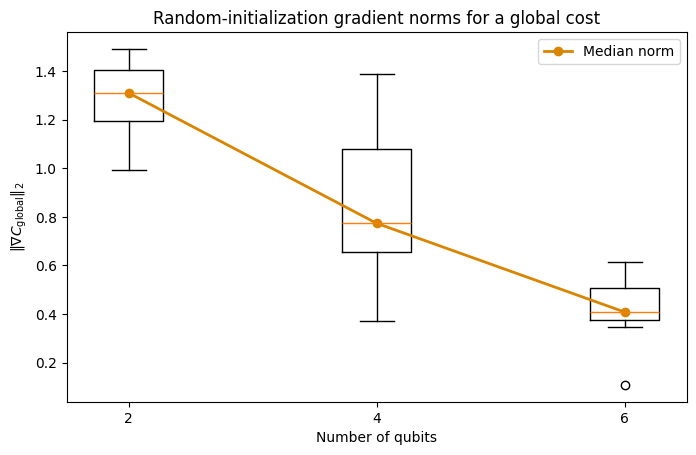

In [2]:
qubit_counts_bp = [2, 4, 6]
depth_bp = 4
repeats_bp = 8
seed_bp = 7

weight_samples_bp = sample_random_weights(qubit_counts_bp, depth_bp, repeats_bp, seed_bp)
stats_bp = gradient_concentration_from_samples(weight_samples_bp, depth_bp, observable="global")

for row in stats_bp:
    print(f"n={row['n_qubits']}: median gradient norm = {row['median_norm']:.4f}")

fig, ax = plt.subplots(figsize=(8.0, 4.8))
positions = [row["n_qubits"] for row in stats_bp]
box_data = [row["norms"] for row in stats_bp]
ax.boxplot(box_data, positions=positions, widths=0.55)
ax.plot(
    positions,
    [row["median_norm"] for row in stats_bp],
    marker="o",
    color="#d98500",
    linewidth=2.0,
    label="Median norm",
)
ax.set_xlabel("Number of qubits")
ax.set_ylabel(r"$\|\nabla C_{\mathrm{global}}\|_2$")
ax.set_title("Random-initialization gradient norms for a global cost")
ax.set_xticks(positions)
ax.legend()
plt.show()


The printed medians and the boxplot should be read together. If the typical gradient norms decrease as the qubit count grows, the experiment is showing exactly the kind of warning sign one worries about in barren-plateau discussions: the optimizer would start from parameter regions where the cost barely changes. The point is not that every single initialization is flat, but that the <b>distribution</b> shifts toward smaller gradients.

This output should also be read cautiously. The experiment is finite, small, and deliberately simplified. It does not claim exponential scaling from a few boxplots. What it does show is that even a moderate increase in circuit size can make gradient information markedly less informative for a global cost.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>A barren plateau is about gradients, not about a large cost value</b><br>
A circuit can have a nontrivial cost value and still be hard to train if nearby parameter changes produce almost no gradient signal. What matters for optimization is not only where the cost sits, but also how sharply it changes in the neighborhood explored by the optimizer.
</div>


### Task 1 (coding): Do local costs flatten less than global ones?

Reuse the same random initializations used in the example above, but compare the global observable $Z_0 \otimes \cdots \otimes Z_{n-1}$ with the local observable $Z_0$ on qubit counts `[2, 4, 6]` and depth `4`. Compute the gradient norms for both observables, report the median norm at each qubit count, and produce one figure that compares the two median curves on the same axes. Then write a short paragraph explaining why the local cost in this finite experiment is less affected by gradient concentration than the global cost.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="03-why-training-fails-noise-and-reproducibility-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>


In [3]:
# Task 1 starter
qubit_counts_bp = [2, 4, 6]
depth_bp = 4
repeats_bp = 8
seed_bp = 7

# TODO:
# 1. reuse one shared set of random initializations for all qubit counts
# 2. compute gradient-norm statistics for both observable="global" and observable="local"
# 3. report the median norm for each observable at each qubit count
# 4. make one figure that compares the two median curves
# 5. summarize why the local cost is less flattened in this finite study


## Finite shots, noisy gradients, and why seeds matter

In the noiseless statevector setting, a quantity such as $s(\vec{x}^{\,j}, \boldsymbol{\theta})$ is an exact expectation value. On hardware, one estimates it from finitely many shots:

$$
\hat s_N(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\frac{1}{N} \sum_{r=1}^{N} m_r,
\qquad
m_r \in \{-1, +1\}
$$

If the supervised objective is $\mathcal{L}_B(\boldsymbol{\theta})$, then a shot-based parameter-shift estimate of one component has the same algebraic form as before,

$$
\widehat{\frac{\partial \mathcal{L}_B}{\partial \theta_m}}
=
\frac{\widehat{\mathcal{L}}_B\!\left(\boldsymbol{\theta} + \frac{\pi}{2}\mathbf{e}_m\right)
-
\widehat{\mathcal{L}}_B\!\left(\boldsymbol{\theta} - \frac{\pi}{2}\mathbf{e}_m\right)}{2}
$$

but now the result depends on the random outcomes used to estimate each shifted objective. Repeating the same estimate under seeds $r = 1, \dots, R$ therefore produces a family of random gradients $\hat g_m^{(r)}$. Their empirical mean and standard deviation are

$$
\bar g_m = \frac{1}{R} \sum_{r=1}^{R} \hat g_m^{(r)},
\qquad
\sigma_m = \sqrt{\frac{1}{R-1} \sum_{r=1}^{R} \bigl(\hat g_m^{(r)} - \bar g_m\bigr)^2}
$$

That is the sense in which seeds matter here: they do not change the exact gradient, but they do change the realized noisy estimator.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Strong components and weak components react differently to shot noise</b><br>
A component whose exact gradient is large can remain sign-stable even at modest shot counts. A component whose exact gradient is already close to zero can flip sign frequently under the same shot budget. So “more noise” is not the whole story: the underlying gradient scale matters just as much.
</div>


## Example 2: Shot noise can hide weak gradient components

We now return to a supervised QML setting. For a two-feature sample $\vec{x}^{\,j} = (x_1^{j}, x_2^{j})$, define the one-qubit reuploading feature map

$$
U_F(\vec{x}^{\,j}) = R_z(x_2^{j}) R_y(x_1^{j})
$$

the trainable single-layer block

$$
U_A(\boldsymbol{\theta}_{\ell}) = R_z(\theta_{2\ell}) R_y(\theta_{2\ell-1}),
\qquad
\boldsymbol{\theta}_{\ell} = (\theta_{2\ell-1}, \theta_{2\ell})
$$

and the full state-preparation rule

$$
|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle
=
\left[\prod_{\ell=1}^{L} U_A(\boldsymbol{\theta}_{\ell}) U_F(\vec{x}^{\,j})\right] |0\rangle
$$

where $\boldsymbol{\theta} = (\theta_1, \dots, \theta_{2L})$. The scalar readout is

$$
s(\vec{x}^{\,j}, \boldsymbol{\theta})
=
f_O(\vec{x}^{\,j}, \boldsymbol{\theta})
=
\langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | Z | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle
$$

and the probability map is still $p = (1+s)/2$. On a batch $B$, the supervised objective is the binary cross-entropy empirical risk

$$
\mathcal{L}_{B,\mathrm{BCE}}(\boldsymbol{\theta})
=
\frac{1}{|B|} \sum_{j \in B} c_{\mathrm{BCE}}\bigl(y^j, p(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

The next cell compares the exact parameter-shift gradient with shot-based estimates over many seeds and several shot counts. Besides the mean norm error, it tracks the component-wise sign-flip rate

$$
\mathrm{flip}_m
=
\frac{1}{R}
\sum_{r=1}^{R}
\mathbf{1}\!\left[
\operatorname{sign}(\hat g_m^{(r)}) \neq \operatorname{sign}(g_m)
\right]
$$

where $g_m$ is the exact gradient component.


exact gradient: [-0.3858  0.2304 -0.688   0.1457 -0.7163 -0.    ]
shots=32: mean norm error = 1.1324, std = 0.2647
shots=64: mean norm error = 0.6929, std = 0.1924
shots=128: mean norm error = 0.4356, std = 0.1224
shots=256: mean norm error = 0.3534, std = 0.0733


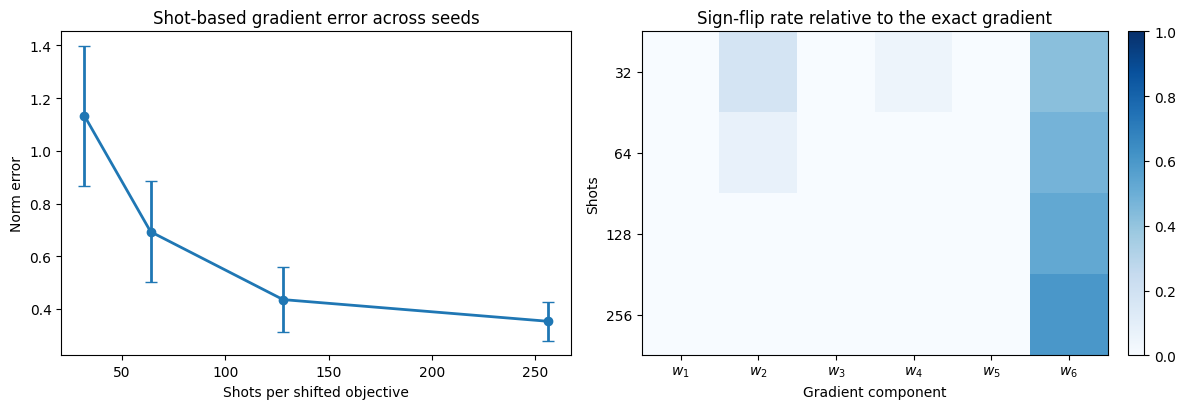

In [4]:
samples_shot, labels_shot = make_moons(n_samples=24, noise=0.18, random_state=4)
samples_shot = (samples_shot - samples_shot.mean(axis=0)) / samples_shot.std(axis=0)
labels_shot = labels_shot.astype(float)

weights_shot = np.array([0.35, -0.40, 0.25, 0.15, -0.20, 0.30])
shot_values = [32, 64, 128, 256]
repeat_seeds = list(range(40))

shot_stats = gradient_reproducibility_statistics(
    samples_shot,
    labels_shot,
    weights_shot,
    shot_values,
    repeat_seeds,
)

print("exact gradient:", np.round(shot_stats["reference_gradient"], 4))
for row in shot_stats["rows"]:
    print(
        f"shots={row['shots']}: mean norm error = {row['mean_norm_error']:.4f}, "
        f"std = {row['std_norm_error']:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))

axes[0].errorbar(
    shot_values,
    [row["mean_norm_error"] for row in shot_stats["rows"]],
    yerr=[row["std_norm_error"] for row in shot_stats["rows"]],
    marker="o",
    linewidth=2.0,
    capsize=4,
)
axes[0].set_xlabel("Shots per shifted objective")
axes[0].set_ylabel("Norm error")
axes[0].set_title("Shot-based gradient error across seeds")

im = axes[1].imshow(
    shot_stats["flip_rate_matrix"],
    aspect="auto",
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
)
axes[1].set_xticks(range(len(weights_shot)))
axes[1].set_xticklabels([rf"$w_{{{m+1}}}$" for m in range(len(weights_shot))])
axes[1].set_yticks(range(len(shot_values)))
axes[1].set_yticklabels([str(shots) for shots in shot_values])
axes[1].set_xlabel("Gradient component")
axes[1].set_ylabel("Shots")
axes[1].set_title("Sign-flip rate relative to the exact gradient")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


The output should be read in two layers. First, the error-bar plot summarizes how far the noisy gradients sit from the exact parameter-shift reference on average. Increasing the shot count should reduce both the mean error and its run-to-run spread, although not every component improves at exactly the same rate.

Second, the heatmap reveals why averages can be misleading. Components with a large exact magnitude usually stabilize first, while components whose exact gradient is already weak can remain sign-unstable for much longer. That does not necessarily mean the implementation is wrong. It means the optimizer is trying to learn from a direction whose signal is already small compared with the sampling noise.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>A seed is not a remedy for shot noise</b><br>
Fixing the seed is essential for reproducibility, but it does not remove estimator variance. It only makes one particular noisy realization repeatable. To understand how reliable the gradient really is, one must still inspect repeated runs, larger shot counts, or both.
</div>


### Task 2 (coding): Which parameter vector is more reproducible under the same shot budget?

Reuse the same batch and shot counts, but compare the reference vector `weights_shot` with the near-stationary vector

```python
weights_flat = np.array([-1.553, -0.169, -1.315, 0.335, -2.024, 1.748])
```

For both vectors, compute the exact gradient, the mean norm error across seeds, and the component-wise sign-flip rates for shots `[32, 64, 128, 256]`. Organize the results in a compact structure, produce one figure that compares the two mean-error curves, and determine which vector is more reproducible under the same shot counts. End with a short paragraph explaining why the answer depends on the underlying gradient magnitudes and not only on the shot count itself.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="03-why-training-fails-noise-and-reproducibility-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>


In [5]:
# Task 2 starter
shot_values = [32, 64, 128, 256]
repeat_seeds = list(range(40))
weights_ref = np.array([0.35, -0.40, 0.25, 0.15, -0.20, 0.30])
weights_flat = np.array([-1.553, -0.169, -1.315, 0.335, -2.024, 1.748])

# TODO:
# 1. run the reproducibility study for both parameter vectors
# 2. collect the exact gradients, mean norm errors, and sign-flip rates
# 3. organize the outputs in a dictionary keyed by the vector name
# 4. make one figure that compares the mean norm error curves
# 5. decide which vector is more reproducible under the same shot counts
# 6. explain why gradient scale matters for this conclusion


## Overfitting on small data and reproducibility across runs

Even if gradients are perfectly available, training can still fail to generalize. In supervised QML, the relevant objects are the training and validation objectives as functions of the optimization step $t$:

$$
\mathcal{L}_{\mathrm{train}}^{(t)},
\qquad
\mathcal{L}_{\mathrm{val}}^{(t)}
$$

A classical warning sign of overfitting is that $\mathcal{L}_{\mathrm{train}}^{(t)}$ keeps decreasing while $\mathcal{L}_{\mathrm{val}}^{(t)}$ stops improving or starts increasing. This motivates an early-stopping checkpoint

$$
t^{\star} = \arg\min_t \mathcal{L}_{\mathrm{val}}^{(t)}
$$

rather than trusting the very last epoch blindly. Reproducibility then adds another layer: if one repeats the same protocol over runs indexed by $k = 1, \dots, K$, with random seeds denoted by $\xi_1, \dots, \xi_K$, any reported test metric should be summarized across runs, for example by

$$
\bar a_{\mathrm{test}} = \frac{1}{K} \sum_{k=1}^{K} a_{\mathrm{test}}^{(k)},
\qquad
\sigma_{\mathrm{test}} = \sqrt{\frac{1}{K-1}\sum_{k=1}^{K}\bigl(a_{\mathrm{test}}^{(k)} - \bar a_{\mathrm{test}}\bigr)^2}
$$

Here $a_{\mathrm{test}}^{(k)}$ denotes the chosen test-set metric measured on run $k$; for example, it may be the test accuracy. Its mean across runs is written as $\bar a_{\mathrm{test}}$, and $\sigma_{\mathrm{test}}$ denotes the corresponding sample standard deviation across runs.

For the repeated-run study below, the same one-qubit model of Example 2 is trained on the training split and monitored on the validation split. That is, each run minimizes

$$
\mathcal{L}_{\mathrm{train}}(\boldsymbol{\theta})
=
\frac{1}{|D_{\mathrm{train}}|}
\sum_{(\vec{x}^{\,j}, y^j) \in D_{\mathrm{train}}}
 c_{\mathrm{BCE}}\bigl(y^j, p(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

while model selection is based on

$$
\mathcal{L}_{\mathrm{val}}(\boldsymbol{\theta})
=
\frac{1}{|D_{\mathrm{val}}|}
\sum_{(\vec{x}^{\,j}, y^j) \in D_{\mathrm{val}}}
 c_{\mathrm{BCE}}\bigl(y^j, p(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

Otherwise, one lucky initialization or one favorable split can be mistaken for stable model behavior.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>A single train/validation/test split is not the same as reproducibility</b><br>
Clean data hygiene is necessary, but it is not sufficient. Two runs can share the same split and still give different conclusions because the parameter initialization, shot sampling, and stopping point are different. Reproducibility requires controlling those sources of variation and then reporting how much variation remains.
</div>


**Implementation note.** Qiskit Algorithms exposes a global seed utility through <a href="https://qiskit-community.github.io/qiskit-algorithms/apidocs/qiskit_algorithms.utils.algorithm_globals.html"><code>algorithm_globals.random_seed</code></a>, while simulators and backends may have their own additional seeding controls. PennyLane lets one seed simulators such as <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.devices.default_qubit.html"><code>default.qubit</code></a> through the device constructor and also requires controlling the random state of the chosen interface; see the <a href="https://docs.pennylane.ai/en/stable/introduction/interfaces/numpy.html">NumPy interface guide</a>. In practice, QML reproducibility usually needs several seeds, not just one. At a higher level, Qiskit Machine Learning models such as <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQC.html"><code>VQC</code></a> and <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQR.html"><code>VQR</code></a> expose a <code>callback</code> argument that can be used to record the objective value during optimization. PennyLane does not provide a single analogous supervised-training callback API in core; in practice, train and validation histories are logged in the outer loop of the chosen interface or around a <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html"><code>qml.qnn.TorchLayer</code></a> model.


## Example 3: Tiny data, label noise, and seed-sensitive outcomes

The next experiment keeps the quantum model intentionally small but makes the learning problem deliberately fragile. The dataset is split into train, validation, and test subsets, then the training set is reduced to only a few samples and a handful of training labels are flipped. This is not meant to imitate a benchmark faithfully. It is meant to make overfitting visible without requiring a large model or a long runtime.

The model is again a one-qubit data-reuploading classifier trained with exact parameter-shift gradients and Adam. We track one representative train/validation curve and then repeat the same protocol under several initialization seeds, always evaluating accuracy with the validation-best weights rather than the last epoch by default.


flipped training-label indices: [1 4 5 2]
{'seed': 2, 'best_epoch': 12, 'best_val_loss': 0.9394904424801369, 'final_val_loss': 1.0374679272206242, 'final_train_loss': 0.07613762026766661, 'train_accuracy': 0.9285714285714286, 'val_accuracy': 0.54, 'test_accuracy': 0.5238095238095238}
{'seed': 7, 'best_epoch': 92, 'best_val_loss': 0.5993386534737306, 'final_val_loss': 0.611896076975491, 'final_train_loss': 0.1264492789076826, 'train_accuracy': 1.0, 'val_accuracy': 0.76, 'test_accuracy': 0.7619047619047619}
{'seed': 19, 'best_epoch': 11, 'best_val_loss': 0.9753372248685244, 'final_val_loss': 1.0442718964387412, 'final_train_loss': 0.074273778846616, 'train_accuracy': 0.9285714285714286, 'val_accuracy': 0.56, 'test_accuracy': 0.5396825396825397}
{'seed': 31, 'best_epoch': 68, 'best_val_loss': 1.0249141340629775, 'final_val_loss': 1.0509936386651306, 'final_train_loss': 0.07433949563034135, 'train_accuracy': 1.0, 'val_accuracy': 0.58, 'test_accuracy': 0.6031746031746031}
{'seed': 43, 'best

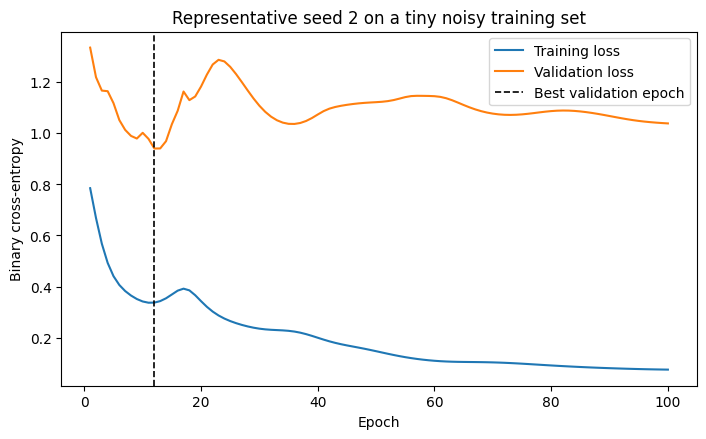

In [6]:
depth_repro = 5
run_seeds_repro = [2, 7, 19, 31, 43]
study_repro = repeated_seed_study(run_seeds_repro, depth=depth_repro, epochs=100)

print("flipped training-label indices:", study_repro["flipped_idx"])
for row in study_repro["rows"]:
    print(row)

best_val_losses = np.array([row["best_val_loss"] for row in study_repro["rows"]])
test_accuracies = np.array([row["test_accuracy"] for row in study_repro["rows"]])
print(f"mean best validation loss: {best_val_losses.mean():.4f} +- {best_val_losses.std(ddof=1):.4f}")
print(f"mean test accuracy: {test_accuracies.mean():.4f} +- {test_accuracies.std(ddof=1):.4f}")

seed_to_plot = run_seeds_repro[0]
history_to_plot = study_repro["histories"][seed_to_plot]
best_epoch_to_plot = next(row["best_epoch"] for row in study_repro["rows"] if row["seed"] == seed_to_plot)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
epochs = np.arange(1, len(history_to_plot["train_loss"]) + 1)
ax.plot(epochs, history_to_plot["train_loss"], label="Training loss")
ax.plot(epochs, history_to_plot["val_loss"], label="Validation loss")
ax.axvline(best_epoch_to_plot, color="black", linestyle="--", linewidth=1.2, label="Best validation epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy")
ax.set_title(f"Representative seed {seed_to_plot} on a tiny noisy training set")
ax.legend()
plt.show()


This output should be read at two levels. The representative loss curves show the classical overfitting pattern: the training objective can continue to improve while the validation objective prefers an earlier checkpoint. That is why the best validation epoch matters. Looking only at the last epoch would exaggerate the apparent quality of the fit to the tiny training set.

The repeated-run summary then adds the reproducibility layer. If the best validation loss and test accuracy vary appreciably across seeds, the model is not giving a single stable answer. In a fragile regime like this one, reporting only the luckiest run would be misleading. The relevant story is the whole distribution across seeds, not the one run that happened to look best.


### Task 3 (coding): How stable is the story across model depth?

Reuse the same repeated-seed protocol, but compare depths `3` and `5` on the same tiny noisy dataset and the same initialization seeds `[2, 7, 19, 31, 43]`. Write one helper that runs the repeated-seed study for a chosen depth and returns, for each seed, the best epoch, best validation loss, final validation loss, train accuracy, validation accuracy, and test accuracy. Then aggregate mean and standard deviation over seeds for each depth, make one figure that compares the distributions of best validation loss and test accuracy, and conclude which depth looks more stable and which one shows stronger signs of overfitting in this small-data regime.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="03-why-training-fails-noise-and-reproducibility-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>


In [7]:
# Task 3 starter
depths_repro = [3, 5]
run_seeds_repro = [2, 7, 19, 31, 43]

# TODO:
# 1. write one helper that calls repeated_seed_study for a chosen depth
# 2. collect the per-seed summaries for both depths
# 3. compute mean and standard deviation of best validation loss and test accuracy
# 4. make one figure that compares the two depths on those metrics
# 5. decide which depth looks more stable and which overfits more strongly


## A practical debugging checklist

Before trusting a difficult QML training run, it is worth checking the following points explicitly:

- start with an exact or noiseless simulator before introducing finite shots;
- inspect initial gradient magnitudes before running a long optimizer loop;
- report train and validation curves separately, not just the final test metric;
- record all seeds that affect the experiment: data split, initialization, and shot sampling;
- repeat the run under several seeds and summarize variability, not only the best case;
- when a model looks unstable, simplify one thing at a time: depth, qubit count, shot setting, or dataset size.

These checks do not guarantee good performance, but they make failure modes visible much earlier and make reported results easier to interpret.


## Key takeaways

- Training can fail because gradients are too small, because estimates are too noisy, or because generalization is weak. Those are different problems.
- Barren plateaus are about gradient concentration, not simply about large loss values.
- Finite-shot gradients should be read statistically: exact references, repeated seeds, and sign stability all matter.
- Small QML datasets can produce severe overfitting and strong run-to-run variability even when optimization itself appears to work.
- Reproducibility in QML requires controlling and reporting multiple sources of randomness, not just one seed.
